<a href="https://colab.research.google.com/github/Shaurya-2004/JS_repo/blob/main/DL_Breast_Cancer_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/200


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 158ms/step - accuracy: 0.5259 - loss: 0.7720 - val_accuracy: 0.6754 - val_loss: 0.6452
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5622 - loss: 0.7362 - val_accuracy: 0.7193 - val_loss: 0.6127
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6321 - loss: 0.6505 - val_accuracy: 0.7368 - val_loss: 0.5834
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5990 - loss: 0.6585 - val_accuracy: 0.7281 - val_loss: 0.5547
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5932 - loss: 0.6314 - val_accuracy: 0.7719 - val_loss: 0.5192
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6085 - loss: 0.6040 - val_accuracy: 0.7807 - val_loss: 0.4815
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6773 - loss: 0.5438 - val_accuracy: 0.8158 - val_loss: 0.4405
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6981 - loss: 0.5330 - val_accuracy: 0.8509 - val_loss: 0.3992
Epo

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Prediction: Benign, Actual: Benign
Prediction: Benign, Actual: Benign
Prediction: Benign, Actual: Benign
Prediction: Benign, Actual: Benign
Prediction: Benign, Actual: Benign
Prediction: Malignant, Actual: Malignant
Prediction: Malignant, Actual: Benign
Prediction: Malignant, Actual: Malignant
Prediction: Malignant, Actual: Malignant
Prediction: Malignant, Actual: Malignant
Prediction: Malignant, Actual: Malignant
Prediction: Benign, Actual: Benign
Prediction: Malignant, Actual: Malignant
Prediction: Malignant, Actual: Malignant
Prediction: Malignant, Actual: Malignant
Prediction: Malignant, Actual: Malignant
Prediction: Benign, Actual: Benign
Prediction: Malignant, Actual: Malignant
Prediction: Malignant, Actual: Malignant
Prediction: Benign, Actual: Benign
Prediction: Benign, Actual: Benign
Prediction: Malignant, Actual: Malignant
Prediction: Malignant, Actual: Malignant
Prediction: Malignant, Actual: Malignant
Prediction: Malignant, Actual: Mali

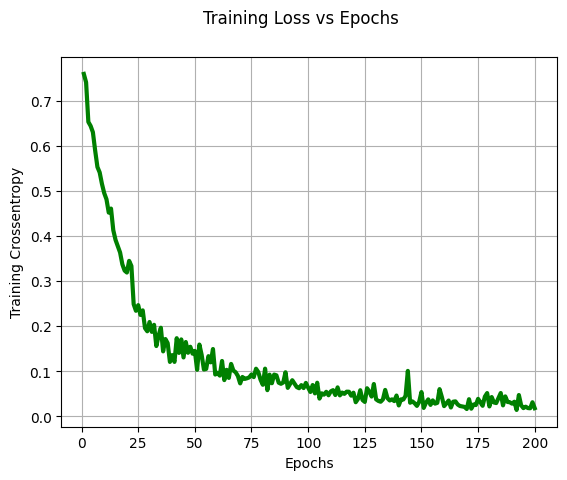

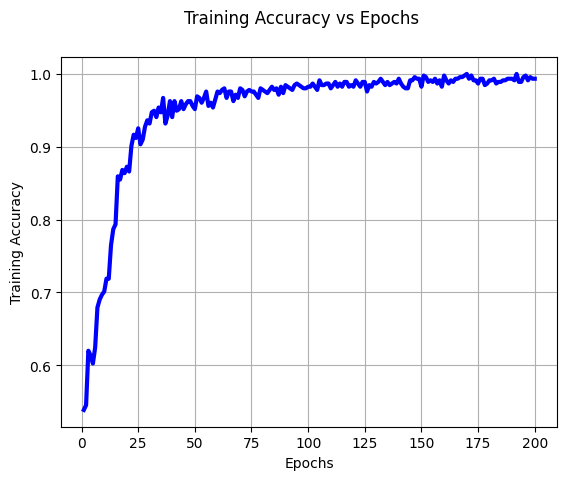

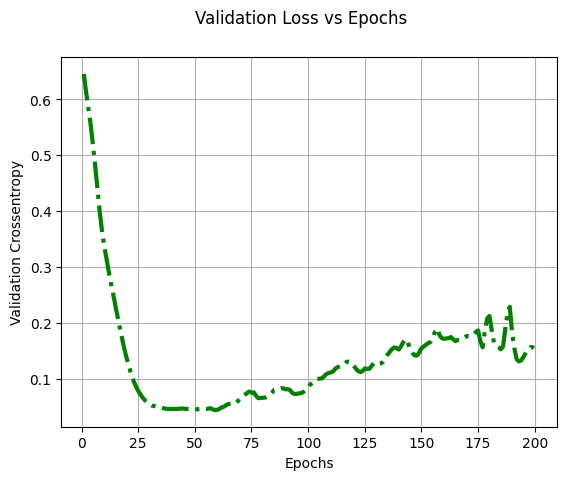

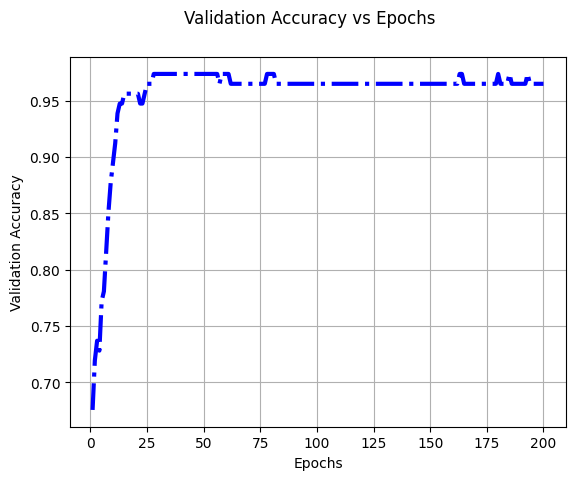

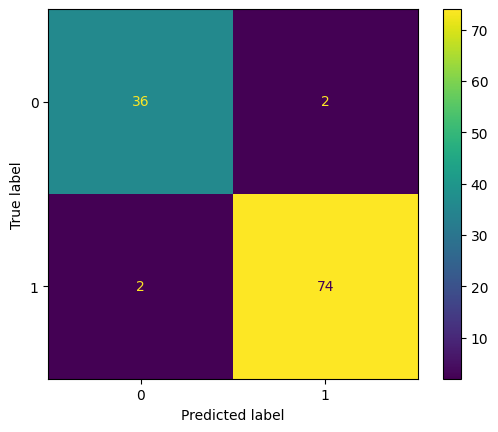

In [4]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

bcancer = datasets.load_breast_cancer()

# Data preprocessing
X = bcancer.data
y = bcancer.target

scaler = StandardScaler()
X = scaler.fit_transform(X)
y = y.reshape(-1, 1)

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=11)

oh = OneHotEncoder()
ytrain = oh.fit_transform(ytrain).toarray()
ytestoh = oh.transform(ytest).toarray()

# Model building
model = Sequential()
model.add(Dense(64, input_shape=(30,), activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

# Training
history = model.fit(Xtrain, ytrain, epochs=200, batch_size=100, validation_data=(Xtest, ytestoh))

# Predictions
ypred = model.predict(Xtest)
ypred = np.argmax(ypred, axis=1)

#Printing
for i in range(len(ypred)):
    prediction = "Malignant" if ypred[i] == 1 else "Benign"
    actual = "Malignant" if ytest[i] == 1 else "Benign"
    print(f"Prediction: {prediction}, Actual: {actual}")


# Evaluation
score = accuracy_score(ypred, np.argmax(ytestoh, axis=1))
print('Accuracy score is', 100 * score, '%')

cmat = confusion_matrix(np.argmax(ytestoh, axis=1), ypred)
print('Confusion matrix of Neural Network is \n', cmat, '\n')

# Plots
plt.plot(range(1, len(history.history['loss']) + 1), history.history['loss'], 'g-', linewidth=3)
plt.xlabel('Epochs')
plt.ylabel('Training Crossentropy')
plt.grid(True, which='both')
plt.suptitle('Training Loss vs Epochs')
plt.show()

plt.plot(range(1, len(history.history['loss']) + 1), history.history['accuracy'], 'b-', linewidth=3)
plt.xlabel('Epochs')
plt.ylabel('Training Accuracy')
plt.grid(True, which='both')
plt.suptitle('Training Accuracy vs Epochs')
plt.show()

plt.plot(range(1, len(history.history['loss']) + 1), history.history['val_loss'], 'g-.', linewidth=3)
plt.xlabel('Epochs')
plt.ylabel('Validation Crossentropy')
plt.grid(True, which='both')
plt.suptitle('Validation Loss vs Epochs')
plt.show()

plt.plot(range(1, len(history.history['loss']) + 1), history.history['val_accuracy'], 'b-.', linewidth=3)
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.grid(True, which='both')
plt.suptitle('Validation Accuracy vs Epochs')
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=cmat)
disp.plot()
